RelaxFlow has the code for TRELLIS but seems to be not used

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("~/Documents/vggt2/digitizing_reality/TRELLIS").expanduser()))

# !pip install pillow imageio imageio-ffmpeg tqdm easydict opencv-python-headless scipy ninja rembg onnxruntime trimesh open3d xatlas pyvista pymeshfix igraph transformers
# !pip install git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8
# !python -m pip install --no-cache-dir --force-reinstall "numpy==1.26.4" "scipy==1.13.1"
# !python -m pip install -U wrapt
# !python -m pip uninstall -y pip-system-certs
# !rm -rf /tmp/extensions/nvdiffrast
# # prevent build isolation on nvdiffrast
# !./TRELLIS/setup.sh --diffoctreerast --spconv --mipgaussian --kaolin --nvdiffrast

In [2]:
import os
# os.environ['ATTN_BACKEND'] = 'xformers'   # Can be 'flash-attn' or 'xformers', default is 'flash-attn'
os.environ['SPCONV_ALGO'] = 'native'        # Can be 'native' or 'auto', default is 'auto'.
                                            # 'auto' is faster but will do benchmarking at the beginning.
                                            # Recommended to set to 'native' if run only once.


import imageio
from PIL import Image
# from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.pipelines.relaxflow_pipeline import TrellisImageTo3DPipelineRelaxFlow

from trellis.utils import render_utils, postprocessing_utils
from matplotlib import pyplot as plt

/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[SPARSE] Backend: spconv, Attention: flash_attn
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090 Ti" (22 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/ahc/.cache/warp/1.12.0
[ATTENTION] Using backend: flash_attn


In [3]:
pipeline = TrellisImageTo3DPipelineRelaxFlow.from_pretrained("microsoft/TRELLIS-image-large")
pipeline.cuda()

[SPARSE][CONV] spconv algo: native


/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/spconv/pytorch/functional.py:96: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/spconv/pytorch/functional.py:162: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/spconv/pytorch/functional.py:242: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `

In [4]:
prior1A = Image.open("eval_data/DUCK/pred0/A yellow rubber duck with a pirate eye patch on its left, white background, centered, 3D render.png")
prior1B = Image.open("eval_data/DUCK/pred1/A yellow rubber duck with left eye blue right eye white, white background, centered, 3D render.png")
prior1C = Image.open("eval_data/DUCK/pred2/A yellow rubber duck with the left eye replaced by a googlie eye, white background, centered, 3D render.png")
prior2A = Image.open("eval_data/FLIP_CALENDAR_RED/pred0/Red flip paper calendar with many binder rings showing month of March, white background, centered, 3D render.png")
prior2B = Image.open("eval_data/FLIP_CALENDAR_RED/pred1/Red flip paper calendar with many binder rings showing month of April (on a yellow paper on top of the red flip calendar), white background, centered, 3D render.png")
prior2C = Image.open("eval_data/FLIP_CALENDAR_RED/pred2/Red flip paper calendar with many binder rings showing with two large flip placards representing the month and the day, white background, centered, 3D render.png")

masked_image1 = Image.open("./eval_data/DUCK/gt_obs_segmented/frame_000000.png")
masked_image2 = Image.open("./eval_data/FLIP_CALENDAR_RED/gt_obs_segmented/frame_000001.png")

In [6]:
import gc
import torch

for masked_img, prior, path in [
    (masked_image1, prior1A, "DUCK/pred0"),
    (masked_image1, prior1B, "DUCK/pred1"),
    (masked_image1, prior1C, "DUCK/pred2"),
    (masked_image2, prior2A, "FLIP_CALENDAR_RED/pred0"),
    (masked_image2, prior2B, "FLIP_CALENDAR_RED/pred1"),
    (masked_image2, prior2C, "FLIP_CALENDAR_RED/pred2"),
]:
    output = pipeline.run_relaxflow(
        masked_img, 
        prior_images=[prior],
        prior_blur_sigma=1.0,
        seed=1,
        return_branch_outputs=True,
    )

    frames = render_utils.render_video(output["relaxflow"]['gaussian'][0], num_frames=10)['color']


    # save each frame
    out_dir = Path(f"./eval_data/{path}/TRELLIS")
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, frame in enumerate(frames):
        imageio.imwrite(out_dir / f"view_{i:02d}.png", frame)

    print(f"Saved {len(frames)} views to {out_dir}")

    del frames, output
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

2026-04-06 20:34:49.897 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]
2026-04-06 20:36:03.484 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:892 - Stage 2: RelaxFlow SLAT sampling
Sampling: 100%|██████████| 25/25 [00:09<00:00,  2.51it/s]
Rendering: 10it [00:00, 145.01it/s]


Saved 10 views to eval_data/DUCK/pred0/TRELLIS


2026-04-06 20:37:06.917 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]
2026-04-06 20:38:20.823 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:892 - Stage 2: RelaxFlow SLAT sampling
Sampling: 100%|██████████| 25/25 [00:07<00:00,  3.52it/s]
Rendering: 10it [00:00, 241.39it/s]


Saved 10 views to eval_data/DUCK/pred1/TRELLIS


2026-04-06 20:39:19.708 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]
2026-04-06 20:40:33.637 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:892 - Stage 2: RelaxFlow SLAT sampling
Sampling: 100%|██████████| 25/25 [00:06<00:00,  3.68it/s]
Rendering: 10it [00:00, 262.18it/s]


...

Saved 10 views to eval_data/FLIP_CALENDAR_RED/pred0/TRELLIS


2026-04-06 20:43:16.530 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]
2026-04-06 20:44:30.477 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:892 - Stage 2: RelaxFlow SLAT sampling
Sampling: 100%|██████████| 25/25 [00:02<00:00, 11.23it/s]
Rendering: 10it [00:00, 469.55it/s]


Saved 10 views to eval_data/FLIP_CALENDAR_RED/pred1/TRELLIS


2026-04-06 20:44:50.429 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]
2026-04-06 20:46:04.379 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:892 - Stage 2: RelaxFlow SLAT sampling
Sampling: 100%|██████████| 25/25 [00:15<00:00,  1.65it/s]
Rendering: 10it [00:00, 268.89it/s]


Saved 10 views to eval_data/FLIP_CALENDAR_RED/pred2/TRELLIS


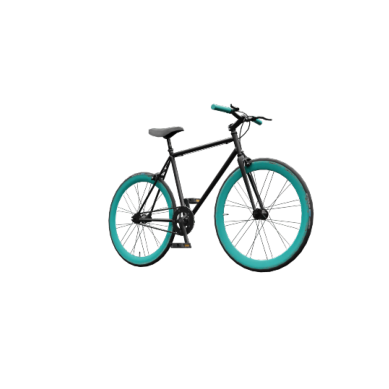

In [5]:
# data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel

# image = Image.open("./data/bike_three_wheels/input.png")
# mask = Image.open("./data/bike_three_wheels/mask.png")
# prior1 = Image.open("./data/bike_three_wheels/prior.jpg")

image = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/image.png")
mask = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/mask.png")
prior1 = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/prior.png")

plt.axis("off")
plt.imshow(image)

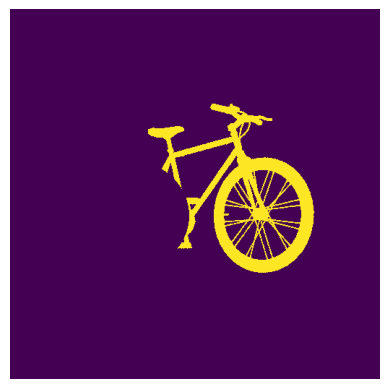

In [6]:
plt.axis("off")
plt.imshow(mask)

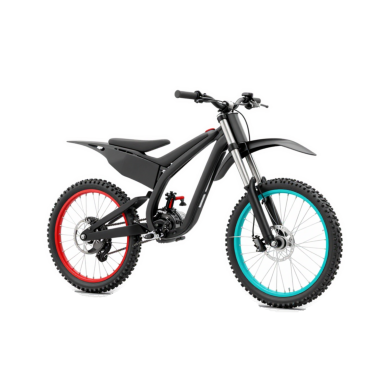

In [7]:
plt.axis("off")
plt.imshow(prior1)

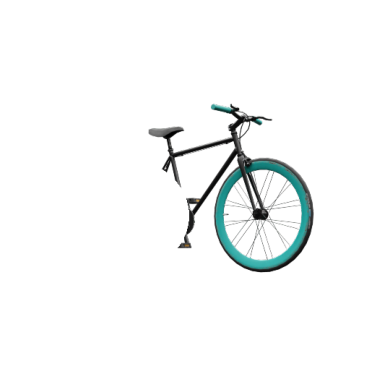

In [8]:
masked_image = Image.composite(image, Image.new('RGBA', image.size, (0,0,0,0)), mask)

plt.axis("off")
plt.imshow(masked_image)

In [9]:
outputs = pipeline.run_relaxflow(
    masked_image,
    prior_images=[prior1],
    seed=1,
    return_branch_outputs=True,
    # Optional parameters
    # sparse_structure_sampler_params={
    #     "steps": 12,
    #     "cfg_strength": 7.5,
    # },
    # slat_sampler_params={
    #     "steps": 12,
    #     "cfg_strength": 3,
    # },
)

2026-04-05 00:28:06.527 | INFO     | trellis.pipelines.relaxflow_pipeline:run_relaxflow:871 - Stage 1: RelaxFlow sparse structure sampling
Sampling:   4%|▍         | 1/25 [00:03<01:31,  3.83s/it]

DEBUG: e_obs magnitude: 4.6043
DEBUG: e_prior magnitude: 3.3613


Sampling:   8%|▊         | 2/25 [00:06<01:15,  3.30s/it]

DEBUG: e_obs magnitude: 4.6247
DEBUG: e_prior magnitude: 3.3445


Sampling:  12%|█▏        | 3/25 [00:09<01:08,  3.13s/it]

...

Sampling:  40%|████      | 10/25 [00:02<00:03,  4.40it/s]

DEBUG: e_obs magnitude: 5.1649
DEBUG: e_prior magnitude: 4.5281


Sampling:  48%|████▊     | 12/25 [00:02<00:02,  5.19it/s]

DEBUG: e_obs magnitude: 4.9596
DEBUG: e_prior magnitude: 4.4492


Sampling: 100%|██████████| 25/25 [00:03<00:00,  6.67it/s]


In [10]:
video = render_utils.render_video(outputs["relaxflow"]['gaussian'][0])['color']
imageio.mimsave("./data/eval/TRELLIS_RelaxFlow_Combined_gs.gif", video, fps=30, loop=0)

video = render_utils.render_video(outputs["obs_only"]['gaussian'][0])['color']
imageio.mimsave("./data/eval/TRELLIS_RelaxFlow_Observation_gs.gif", video, fps=30, loop=0)

video = render_utils.render_video(outputs["prior_only"]['gaussian'][0])['color']
imageio.mimsave("./data/eval/TRELLIS_RelaxFlow_Prior_gs.gif", video, fps=30, loop=0)

Rendering: 300it [00:00, 519.21it/s]
Rendering: 300it [00:00, 562.03it/s]
Rendering: 300it [00:00, 380.77it/s]


In [11]:
outputs.keys()

dict_keys(['relaxflow', 'blend_then_obs', 'blend_then_prior', 'obs_only', 'prior_only'])